# ISOM5240 Model Comparison — Pipeline 1 & Pipeline 3

**Pipeline 1:** Product image → Shelf-life category (short / medium / non-perishable)  
**Pipeline 3:** Product image → Auto-generated text description  

Both pipelines use pre-trained models. This notebook compares 3 candidates for each and selects the best.

**Datasets used for Pipeline 1 testing:**
- Grocery Store Dataset (GitHub) → short_shelf + medium_shelf
- Kaggle Household Products → non_perishable

## Step 1: Install dependencies

In [6]:
!pip install transformers pillow -q

## Step 2: GPU check

In [5]:
import torch
import os
import time
import numpy as np

if torch.cuda.is_available():
    DEVICE = 0
    print(f"Using GPU: {torch.cuda.get_device_name(0)}")
else:
    DEVICE = -1
    print("No GPU, using CPU (fine — no training needed)")

Using GPU: Tesla T4


## Step 3: Setup Kaggle credentials

In [7]:
from google.colab import userdata

os.environ["KAGGLE_USERNAME"] = userdata.get('KAGGLE_USERNAME')
os.environ["KAGGLE_KEY"] = userdata.get('KAGGLE_KEY')
print("Kaggle credentials set")

Kaggle credentials set


## Step 4: Download both datasets

1. Grocery Store Dataset (GitHub) → fruits, vegetables, dairy
2. Kaggle Household Products → tissue, cleaning supplies, etc.

In [8]:
# Dataset 1: Grocery Store Dataset
!git clone https://github.com/marcusklasson/GroceryStoreDataset.git
print("Grocery Store Dataset downloaded")

# Dataset 2: Household Products
!kaggle datasets download -d taru149/householdproducts
!unzip -q householdproducts.zip -d household/
print("Household Products downloaded")

# Check structure
print("\nGrocery Store test folders:")
grocery_test = "GroceryStoreDataset/dataset/test"
if os.path.exists(grocery_test):
    print(os.listdir(grocery_test))

print("\nHousehold folders:")
!find household/ -type d | head -20

Cloning into 'GroceryStoreDataset'...
remote: Enumerating objects: 6559, done.
remote: Counting objects: 100% (264/264), done.
remote: Compressing objects: 100% (229/229), done.
remote: Total 6559 (delta 45), reused 35 (delta 35), pack-reused 6295 (from 2)
Receiving objects: 100% (6559/6559), 116.26 MiB | 26.12 MiB/s, done.
Resolving deltas: 100% (275/275), done.
Grocery Store Dataset downloaded
Dataset URL: https://www.kaggle.com/datasets/taru149/householdproducts
License(s): unknown
100% 33.4M/33.4M [00:00<00:00, 72.3MB/s]

Household Products downloaded

Grocery Store test folders:
['Packages', 'Vegetables', 'Fruit']

Household folders:
household/
household/Household-Products
household/Household-Products/validation
household/Household-Products/validation/annotations
household/Household-Products/validation/images
household/Household-Products/train
household/Household-Products/train/annotations
household/Household-Products/train/images


## Step 5: Build combined 3-class test set

- short_shelf (0): fruits, vegetables from Grocery Store Dataset
- medium_shelf (1): dairy, juice from Grocery Store Dataset
- non_perishable (2): household products from Kaggle

In [9]:
from PIL import Image
import glob

DATA_ROOT = "GroceryStoreDataset/dataset"

# Shelf-life keywords
SHORT_KEYWORDS = [
    "apple", "avocado", "banana", "kiwi", "lemon", "lime", "mango",
    "melon", "nectarine", "orange", "papaya", "passion", "peach",
    "pear", "pineapple", "plum", "pomegranate", "grapefruit",
    "satsuma", "watermelon", "asparagus", "aubergine", "cabbage",
    "carrot", "cucumber", "garlic", "ginger", "leek", "mushroom",
    "onion", "pepper", "potato", "red-beet", "tomato", "zucchini"
]

MEDIUM_KEYWORDS = [
    "juice", "milk", "oat", "sour-cream", "sour-milk",
    "soy", "yoghurt", "cream"
]

LABEL_NAMES_P1 = ["short_shelf", "medium_shelf", "non_perishable"]

# Collect from Grocery Store Dataset (recursive)
test_images = []
test_labels = []

test_dir = os.path.join(DATA_ROOT, "test")
for root, dirs, files in os.walk(test_dir):
    folder_name = os.path.basename(root).lower()

    if any(kw in folder_name for kw in SHORT_KEYWORDS):
        label = 0
    elif any(kw in folder_name for kw in MEDIUM_KEYWORDS):
        label = 1
    else:
        continue

    for f in files:
        if f.lower().endswith((".jpg", ".jpeg", ".png", ".bmp", ".gif", ".webp")):
            test_images.append(os.path.join(root, f))
            test_labels.append(label)

# Collect from Household Products (all = non_perishable)
household_paths = (glob.glob("household/**/*.jpg", recursive=True) +
                   glob.glob("household/**/*.png", recursive=True) +
                   glob.glob("household/**/*.jpeg", recursive=True))

for path in household_paths:
    test_images.append(path)
    test_labels.append(2)

test_labels = np.array(test_labels)
print(f"Combined test set: {len(test_images)} images")
print(f"  short_shelf (0):    {(test_labels==0).sum()}")
print(f"  medium_shelf (1):   {(test_labels==1).sum()}")
print(f"  non_perishable (2): {(test_labels==2).sum()}")

Combined test set: 2390 images
  short_shelf (0):    1456
  medium_shelf (1):   586
  non_perishable (2): 348


---
# Pipeline 1: Shelf-life Classification

## Step 6: Define ImageNet → shelf-life keyword mapping

In [15]:
# ImageNet label → shelf-life category
IMAGENET_SHORT = [
    "banana", "orange", "strawberry", "apple", "lemon", "pineapple",
    "pomegranate", "fig", "jackfruit", "mango", "broccoli", "cucumber",
    "mushroom", "meat", "egg", "bakery", "bread", "grocery", "fruit",
    "vegetable", "food", "pizza", "hotdog", "pretzel", "bagel", "dough",
    "zucchini", "pepper", "cauliflower", "artichoke", "potato", "cabbage",
    "head cabbage", "corn", "acorn squash", "spaghetti squash",
    "butternut squash", "ice cream", "custard apple"
]

IMAGENET_MEDIUM = [
    "bottle", "can", "jar", "packet", "carton", "sauce", "wine",
    "beer", "juice", "water", "pop", "cup", "coffee", "espresso",
    "milk can", "water bottle", "wine bottle", "beer bottle", "pop bottle"
]

IMAGENET_NON_PERISHABLE = [
    "toilet paper", "paper towel", "soap", "lotion", "shampoo",
    "detergent", "cleaner", "sponge", "brush", "broom", "bucket",
    "basket", "bag", "plastic bag", "trash", "diaper", "tissue",
    "rubber eraser", "pencil", "pen", "notebook", "envelope",
    "container", "box", "crate", "packet", "carton",
    "vacuum", "iron", "washer", "dryer", "lamp", "candle",
    "lighter", "match", "battery", "plug", "switch", "remote",
    "mouse", "keyboard", "monitor", "television", "radio",
    "phone", "calculator", "clock", "watch"
]

def map_to_shelf_life(imagenet_label):
    label = imagenet_label.lower()
    if any(kw in label for kw in IMAGENET_SHORT):
        return 0  # short_shelf
    elif any(kw in label for kw in IMAGENET_MEDIUM):
        return 1  # medium_shelf
    elif any(kw in label for kw in IMAGENET_NON_PERISHABLE):
        return 2  # non_perishable
    else:
        return 2  # default: non_perishable (not food = no expiry concern)

print("3-class keyword mapping ready")

3-class keyword mapping ready


## Step 7: Compare 3 models on Pipeline 1

In [16]:
from transformers import pipeline as hf_pipeline
import pandas as pd

PIPELINE1_MODELS = {
    "ViT-base": "google/vit-base-patch16-224",
    "ResNet-50": "microsoft/resnet-50",
    "Swin-tiny": "microsoft/swin-tiny-patch4-window7-224",
}

def evaluate_p1(model_key, model_path, test_images, test_labels):
    print(f"\nEvaluating: {model_key}")

    pipe = hf_pipeline("image-classification", model=model_path, device=DEVICE)
    total_params = sum(p.numel() for p in pipe.model.parameters())

    correct = 0
    total = len(test_images)
    inference_times = []

    for i in range(total):
        img = Image.open(test_images[i]).convert("RGB")

        t0 = time.time()
        result = pipe(img, top_k=1)
        inference_times.append(time.time() - t0)

        pred = map_to_shelf_life(result[0]["label"])
        if pred == test_labels[i]:
            correct += 1

    accuracy = correct / total
    avg_ms = np.mean(inference_times) * 1000

    print(f"  Accuracy: {accuracy:.4f} | Speed: {avg_ms:.1f}ms | Params: {total_params/1e6:.1f}M")

    return {
        "Model": model_key,
        "Parameters (M)": f"{total_params/1e6:.1f}M",
        "Accuracy": round(accuracy, 4),
        "Avg Inference (ms)": round(avg_ms, 1),
        "Test Samples": total,
    }

In [ ]:
# Run Pipeline 1 comparison
p1_results = []

for key, path in PIPELINE1_MODELS.items():
    r = evaluate_p1(key, path, test_images, test_labels)
    p1_results.append(r)

df_p1 = pd.DataFrame(p1_results)
print("\n" + "="*60)
print("PIPELINE 1 RESULTS: Shelf-life Classification (3 classes)")
print("="*60)
print(df_p1.to_string(index=False))


Evaluating: ViT-base


Loading weights:   0%|          | 0/200 [00:00<?, ?it/s]

Fast image processor class <class 'transformers.models.vit.image_processing_vit_fast.ViTImageProcessorFast'> is available for this model. Using slow image processor class. To use the fast image processor class set `use_fast=True`.


## Step 8: Select best model for Pipeline 1

In [ ]:
best_p1 = max(p1_results, key=lambda x: x["Accuracy"])
print(f"Best for Pipeline 1: {best_p1['Model']}")
print(f"  Accuracy: {best_p1['Accuracy']}")
print(f"  Speed: {best_p1['Avg Inference (ms)']}ms")
print(f"\n→ Use this model in app.py: load_shelf_life_classifier()")

---
# Pipeline 3: Image Captioning

## Step 9: Compare 3 captioning models

No accuracy metric for captioning — compare inference speed + output quality.

In [ ]:
# Select diverse samples: 2 short, 2 medium, 2 non_perishable
diverse_indices = []
for label_id in [0, 1, 2]:
    indices = [i for i, l in enumerate(test_labels) if l == label_id]
    diverse_indices.extend(indices[:2])

diverse_images = [test_images[i] for i in diverse_indices]
print(f"Selected {len(diverse_images)} diverse images: 2 short + 2 medium + 2 non_perishable")

In [23]:
PIPELINE3_MODELS = {
    "BLIP-base": "Salesforce/blip-image-captioning-base",
    "BLIP-large": "Salesforce/blip-image-captioning-large",
    "GIT-base": "microsoft/git-base-coco",
}

def evaluate_p3(model_key, model_path, image_paths, num_samples=20):
    print(f"\nEvaluating: {model_key}")

    pipe = hf_pipeline("image-text-to-text", model=model_path, device=DEVICE)
    total_params = sum(p.numel() for p in pipe.model.parameters())

    inference_times = []
    sample_outputs = []

    n = min(num_samples, len(image_paths))
    for i in range(n):
        img = Image.open(image_paths[i]).convert("RGB")
        t0 = time.time()
        result = pipe(img, text="a photo of", max_new_tokens=50)
        inference_times.append(time.time() - t0)

        # Save output for display
        if isinstance(result, list) and len(result) > 0:
            item = result[0]
            if isinstance(item, dict):
                text = item.get("generated_text", str(item))
            elif isinstance(item, list) and len(item) > 0:
                text = item[0].get("generated_text", str(item[0]))
            else:
                text = str(item)
        else:
            text = str(result)
        sample_outputs.append(text)

    avg_ms = np.mean(inference_times) * 1000

    print(f"  Speed: {avg_ms:.1f}ms | Params: {total_params/1e6:.1f}M")
    print(f"  Sample outputs:")
    for j, s in enumerate(sample_outputs):
        print(f"    [{j+1}] {s}")

    return {
        "Model": model_key,
        "Parameters (M)": f"{total_params/1e6:.1f}M",
        "Avg Inference (ms)": round(avg_ms, 1),
        "Samples Tested": n,
        "Sample Output": sample_outputs[0] if sample_outputs else "",
    }

In [25]:
# Run Pipeline 3 comparison
p3_results = []

for key, path in PIPELINE3_MODELS.items():
    r = evaluate_p3(key, path, diverse_images)
    p3_results.append(r)

df_p3 = pd.DataFrame(p3_results)
print("\n" + "="*60)
print("PIPELINE 3 RESULTS: Image Captioning")
print("="*60)
print(df_p3[["Model", "Parameters (M)", "Avg Inference (ms)"]].to_string(index=False))


Evaluating: BLIP-base


Loading weights:   0%|          | 0/473 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie text_decoder.cls.predictions.bias to text_decoder.cls.predictions.decoder.bias, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
The tied weights mapping and config for this model specifies to tie text_decoder.bert.embeddings.word_embeddings.weight to text_decoder.cls.predictions.decoder.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
BlipForConditionalGeneration LOAD REPORT from: Salesforce/blip-image-captioning-base
Key                                       | Status     |  | 
------------------------------------------+------------+--+-
text_decoder.bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identic

  Speed: 301.3ms | Params: 247.4M
  Sample outputs:
    [1] a photo of a person holding a box of orange juice
    [2] a photo of a person holding a box of food
    [3] a photo of someone holding a carton of milk
    [4] a photo of a hand holding a bottle of milk
    [5] a photo of a bottle of herbal hair care products

Evaluating: BLIP-large


Loading weights:   0%|          | 0/616 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie text_decoder.bert.embeddings.word_embeddings.weight to text_decoder.cls.predictions.decoder.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
BlipForConditionalGeneration LOAD REPORT from: Salesforce/blip-image-captioning-large
Key                                       | Status     |  | 
------------------------------------------+------------+--+-
text_decoder.bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
Both `max_new_tokens` (=50) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=50) and `max_lengt

  Speed: 320.9ms | Params: 469.7M
  Sample outputs:
    [1] a photo of a person holding a carton of orange juice
    [2] a photo of a person holding a carton of orange juice
    [3] a photo of a person holding a carton of milk in front of a refrigerator
    [4] a photo of a person holding a carton of milk in front of a shelf
    [5] a photo of two bottles of shampooe sitting on a table

Evaluating: GIT-base


Loading weights:   0%|          | 0/305 [00:00<?, ?it/s]

GitForCausalLM LOAD REPORT from: microsoft/git-base-coco
Key                                                    | Status     |  | 
-------------------------------------------------------+------------+--+-
git.embeddings.position_ids                            | UNEXPECTED |  | 
git.image_encoder.vision_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
Both `max_new_tokens` (=50) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=50) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=50) an

  Speed: 86.3ms | Params: 176.6M
  Sample outputs:
    [1] a photo of - breakfast in a supermarket
    [2] a photo of - - a person holding a bottle of juice in hand and a bottle of juice
    [3] a photo of a person holding a carton of milk in a supermarket
    [4] a photo of milk in a supermarket.
    [5] a photo of product line

PIPELINE 3 RESULTS: Image Captioning
     Model Parameters (M)  Avg Inference (ms)
 BLIP-base         247.4M               301.3
BLIP-large         469.7M               320.9
  GIT-base         176.6M                86.3


## Step 10: Select best model for Pipeline 3

In [26]:
best_p3 = min(p3_results, key=lambda x: x["Avg Inference (ms)"])
print(f"Fastest for Pipeline 3: {best_p3['Model']} ({best_p3['Avg Inference (ms)']}ms)")
print(f"\nAlso review sample outputs above — pick the one with best quality if speeds are similar.")
print(f"→ Use selected model in app.py: load_image_captioner()")

Fastest for Pipeline 3: GIT-base (86.3ms)

Also review sample outputs above — pick the one with best quality if speeds are similar.
→ Use selected model in app.py: load_image_captioner()


Loading weights:   0%|          | 0/473 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie text_decoder.cls.predictions.bias to text_decoder.cls.predictions.decoder.bias, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
The tied weights mapping and config for this model specifies to tie text_decoder.bert.embeddings.word_embeddings.weight to text_decoder.cls.predictions.decoder.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
BlipForConditionalGeneration LOAD REPORT from: Salesforce/blip-image-captioning-base
Key                                       | Status     |  | 
------------------------------------------+------------+--+-
text_decoder.bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identic

Loading weights:   0%|          | 0/473 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie text_decoder.cls.predictions.bias to text_decoder.cls.predictions.decoder.bias, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
The tied weights mapping and config for this model specifies to tie text_decoder.bert.embeddings.word_embeddings.weight to text_decoder.cls.predictions.decoder.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
BlipForConditionalGeneration LOAD REPORT from: Salesforce/blip-image-captioning-base
Key                                       | Status     |  | 
------------------------------------------+------------+--+-
text_decoder.bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identic

Loading weights:   0%|          | 0/616 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie text_decoder.bert.embeddings.word_embeddings.weight to text_decoder.cls.predictions.decoder.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
BlipForConditionalGeneration LOAD REPORT from: Salesforce/blip-image-captioning-large
Key                                       | Status     |  | 
------------------------------------------+------------+--+-
text_decoder.bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/305 [00:00<?, ?it/s]

GitForCausalLM LOAD REPORT from: microsoft/git-base-coco
Key                                                    | Status     |  | 
-------------------------------------------------------+------------+--+-
git.embeddings.position_ids                            | UNEXPECTED |  | 
git.image_encoder.vision_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
Both `max_new_tokens` (=50) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=50) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=50) an

Image,BLIP-base,BLIP-large,GIT-base
Arla-Lactose-Medium-Fat-Milk_016.jpg,a photo of someone holding a carton of milk,a photo of a person holding a carton of milk in front of a refrigerator,a photo of a person holding a carton of milk in a supermarket
Arla-Lactose-Medium-Fat-Milk_017.jpg,a photo of a hand holding a bottle of milk,a photo of a person holding a carton of milk in front of a shelf,a photo of milk in a supermarket.
Arla-Lactose-Medium-Fat-Milk_008.jpg,a photo of a person holding a bottle of milk,a photo of a person holding a carton of milk in front of a refrigerator,a photo of milk in a supermarket.
Arla-Lactose-Medium-Fat-Milk_018.jpg,a photo of a hand holding a carton of milk,a photo of a person holding a carton of milk in a store,a photo of milk carton of milk in a supermarket.
Arla-Lactose-Medium-Fat-Milk_013.jpg,a photo of a person ' s hand holding a box of baby formulas,a photo of a person holding a carton of milk in a store,a photo of a person holding a carton of milk in front of a carton of a carton of a box.

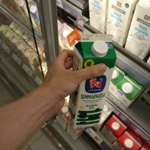
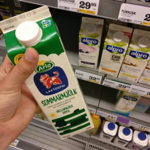
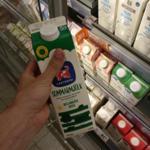
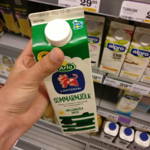
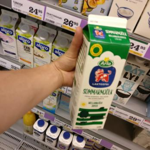

In [27]:
from IPython.display import display, HTML
import base64
from io import BytesIO

# Load all 3 models
pipes = {
    "BLIP-base": hf_pipeline("image-text-to-text", model="Salesforce/blip-image-captioning-base", device=DEVICE),
    "BLIP-large": hf_pipeline("image-text-to-text", model="Salesforce/blip-image-captioning-large", device=DEVICE),
    "GIT-base": hf_pipeline("image-text-to-text", model="microsoft/git-base-coco", device=DEVICE),
}

html = "<h3>Image vs Caption Quality Review</h3>"
html += "<table border='1' style='border-collapse:collapse; font-size:13px'>"
html += "<tr><th style='padding:8px'>Image</th><th style='padding:8px'>BLIP-base</th><th style='padding:8px'>BLIP-large</th><th style='padding:8px'>GIT-base</th></tr>"

for i in range(len(diverse_images)):
    img = Image.open(diverse_images[i]).convert("RGB")

    # Convert image to base64 for inline display
    buf = BytesIO()
    img.resize((150, 150)).save(buf, format="PNG")
    img_b64 = base64.b64encode(buf.getvalue()).decode()

    captions = {}
    for name, pipe in pipes.items():
        result = pipe(img, text="a photo of", max_new_tokens=50)
        if isinstance(result, list) and len(result) > 0:
            item = result[0]
            if isinstance(item, dict):
                captions[name] = item.get("generated_text", str(item))
            elif isinstance(item, list):
                captions[name] = item[0].get("generated_text", str(item[0]))
        else:
            captions[name] = str(result)

    # Get category label for this image
    cat_label = ["short", "medium", "non_perishable"][test_labels[diverse_indices[i]]]
    fname = os.path.basename(diverse_images[i])

    html += f"<tr>"
    html += f"<td style='padding:8px'><img src='data:image/png;base64,{img_b64}' width='150'><br><small>{fname}<br>({cat_label})</small></td>"
    html += f"<td style='padding:8px'>{captions.get('BLIP-base','')}</td>"
    html += f"<td style='padding:8px'>{captions.get('BLIP-large','')}</td>"
    html += f"<td style='padding:8px'>{captions.get('GIT-base','')}</td>"
    html += f"</tr>"

html += "</table>"
display(HTML(html))

## Step 11: Export results to Excel

In [22]:
with pd.ExcelWriter("Pipeline1_3_Experiments.xlsx") as writer:
    df_p1.to_excel(writer, sheet_name="P1 Shelf-life", index=False)
    df_p3[["Model", "Parameters (M)", "Avg Inference (ms)", "Sample Output"]].to_excel(
        writer, sheet_name="P3 Captioning", index=False
    )

print("Saved to Pipeline1_3_Experiments.xlsx")

from google.colab import files
files.download("Pipeline1_3_Experiments.xlsx")
print("Downloaded!")

IndexError: At least one sheet must be visible

---
## Notebook Summary

| Step | Content |
|------|---------|
| 1-3 | Setup: dependencies, GPU check, Kaggle credentials |
| 4-5 | Download Grocery Store Dataset + Household Products, build 3-class test set |
| 6-8 | **Pipeline 1:** ViT vs ResNet vs Swin + keyword mapping → 3-class accuracy + speed → select best |
| 9-10 | **Pipeline 3:** BLIP-base vs BLIP-large vs ViT-GPT2 → speed + quality → select best |
| 11 | Export Excel + auto-download |

**Datasets:**
- Grocery Store Dataset: https://github.com/marcusklasson/GroceryStoreDataset
- Kaggle Household Products: https://www.kaggle.com/datasets/taru149/householdproducts